# Hierarchisch Clusteren - deel 1: Data & Visualisatie

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

## The Data

In [4]:
df = pd.read_csv('../data/cluster_mpg.csv')

In [5]:
df = df.dropna()

In [6]:
df.head()

,mpg,cylinders,displacement,horsepower,weight,acceleration,model_year,origin,name
0,18.0,8,307.0,130.0,3504,12.0,70,usa,chevrolet chevelle malibu
1,15.0,8,350.0,165.0,3693,11.5,70,usa,buick skylark 320
2,18.0,8,318.0,150.0,3436,11.0,70,usa,plymouth satellite
3,16.0,8,304.0,150.0,3433,12.0,70,usa,amc rebel sst
4,17.0,8,302.0,140.0,3449,10.5,70,usa,ford torino


De kolom "naam" is uniek per rij en dus eerder een label.  Dit is niet handig om te clusteren en mag dus worden verwijderd.  Origin kunnen we verder bekijken!

In [7]:
df.describe()

,mpg,cylinders,displacement,horsepower,weight,acceleration,model_year
count,392.000000,392.000000,392.000000,392.000000,392.000000,392.000000,392.000000
mean,23.445918,5.471939,194.411990,104.469388,2977.584184,15.541327,75.979592
std,7.805007,1.705783,104.644004,38.491160,849.402560,2.758864,3.683737
min,9.000000,3.000000,68.000000,46.000000,1613.000000,8.000000,70.000000
25%,17.000000,4.000000,105.000000,75.000000,2225.250000,13.775000,73.000000
50%,22.750000,4.000000,151.000000,93.500000,2803.500000,15.500000,76.000000
75%,29.000000,8.000000,275.750000,126.000000,3614.750000,17.025000,79.000000
max,46.600000,8.000000,455.000000,230.000000,5140.000000,24.800000,82.000000


Merk op dat er een groot verschil is in de range van de waarden: vb cilinders is vb een range van 3 tot 8, terwijl weight in de duizenden zit.

In [8]:
# Origin:
df['origin'].value_counts()

origin
usa       245
japan      79
europe     68
Name: count, dtype: int64

Er zijn slechts 3 soorten origin, dus we kunnen eenvoudig dummy variables aanmaken.  We moeten wel oppassen dat we geen dummy variabele aanmaken voor elk van de unieke namen, dus verwijderen we dit uit de dataset voor we de dummies maken!

In [9]:
df_w_dummies = pd.get_dummies(df.drop('name',axis=1))

In [10]:
df_w_dummies

,mpg,cylinders,displacement,horsepower,weight,acceleration,model_year,origin_europe,origin_japan,origin_usa
0,18.0,8,307.0,130.0,3504,12.0,70,False,False,True
1,15.0,8,350.0,165.0,3693,11.5,70,False,False,True
2,18.0,8,318.0,150.0,3436,11.0,70,False,False,True
3,16.0,8,304.0,150.0,3433,12.0,70,False,False,True
4,17.0,8,302.0,140.0,3449,10.5,70,False,False,True
...,...,...,...,...,...,...,...,...,...,...
387,27.0,4,140.0,86.0,2790,15.6,82,False,False,True
388,44.0,4,97.0,52.0,2130,24.6,82,True,False,False
389,32.0,4,135.0,84.0,2295,11.6,82,False,False,True
390,28.0,4,120.0,79.0,2625,18.6,82,False,False,True


-----

Om te bepalen of we de data moeten schalen of niet, kunnen we nagaan of er een soort afstandsparameter in het algoritme wordt gebruikt.  Hier is dit het geval, dus moeten we schalen!Via de MinMaxScaler kunnen we achteraf eenvoudig inschatten wat de maximum afstand voor een feature is tussen 2 datapunten: 1.

In [11]:
from sklearn.preprocessing import MinMaxScaler

In [12]:
scaler = MinMaxScaler()

In [13]:
scaled_data = scaler.fit_transform(df_w_dummies)

In [14]:
scaled_data

array([[0.2393617 , 1.        , 0.61757106, ..., 0.        , 0.        ,
        1.        ],
       [0.15957447, 1.        , 0.72868217, ..., 0.        , 0.        ,
        1.        ],
       [0.2393617 , 1.        , 0.64599483, ..., 0.        , 0.        ,
        1.        ],
       ...,
       [0.61170213, 0.2       , 0.17312661, ..., 0.        , 0.        ,
        1.        ],
       [0.50531915, 0.2       , 0.13436693, ..., 0.        , 0.        ,
        1.        ],
       [0.58510638, 0.2       , 0.13178295, ..., 0.        , 0.        ,
        1.        ]], shape=(392, 10))

In [15]:
# Opnieuw omzetten van numpy array naar dataframe om bij visualisatie de kolomnamen te zien
scaled_df = pd.DataFrame(scaled_data,columns=df_w_dummies.columns)

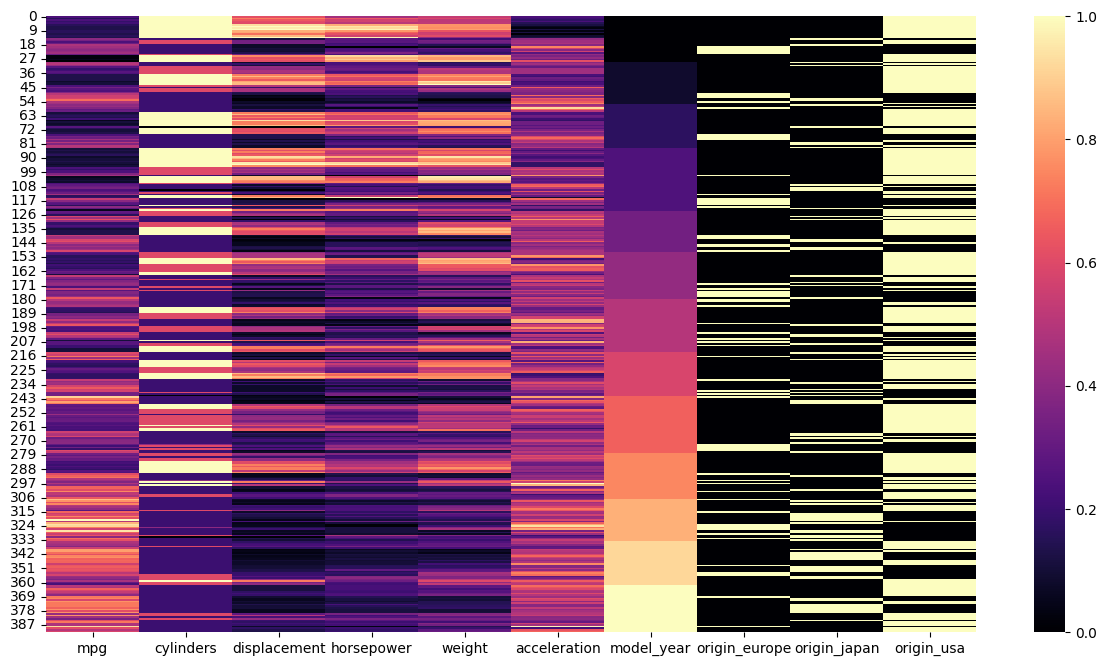

In [16]:
# wat kan seaborn ons geven?
plt.figure(figsize=(15,8))
sns.heatmap(scaled_df,cmap='magma');

**Interpretatie bovenstaande plot:**
<p>we hebben 1 rij per wagen (392 rijen)</p>
<p>alles is geschaald, en voor de origin hebben we dummy variabelen: 0 of 1.  Daardoor zijn er voor origin geen kleurschakeringen; er zijn enkel 2 waarden / kleuren.</p>
<p>Bij model_year hebben we een mooi verloop van kleur.  Dit komt omdat de dataset gesorteerd is op modeljaar van de wagens.</p>
De andere kolommen zijn continu en geschaald, en dit is dus moeilijker te interpreteren.</p>
<p>Daarom gaan we nu verder met een clustermap:</p>

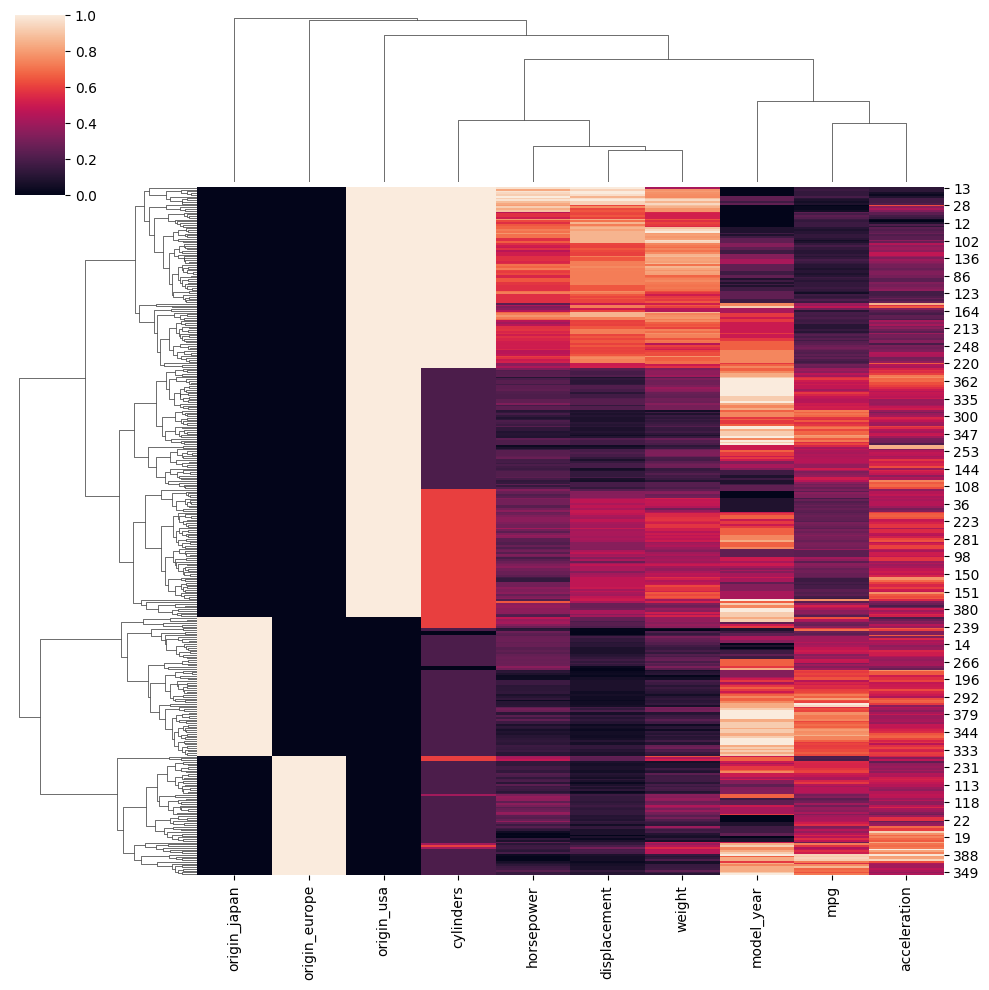

In [17]:
# Initieel werken we met de volledig standaard clustermap
sns.clustermap(scaled_df)

Standaard zal seaborn clusteren langs zowel rijen als kolommen.  Eigenlijk is ons doel om gelijkaardige wagens te clusteren, en aangezien rijen wagens voorstellen willen we rijen clusteren, geen kolommen.  Het clusteren van kolommen vertelt ons welke features aan elkaar gerelateerd zijn.  Als we dit willen weten doen we dit normaal met een plot van de correlatie tussen de features!  Laat ons dit even verder bekijken en enkel de features clusteren:

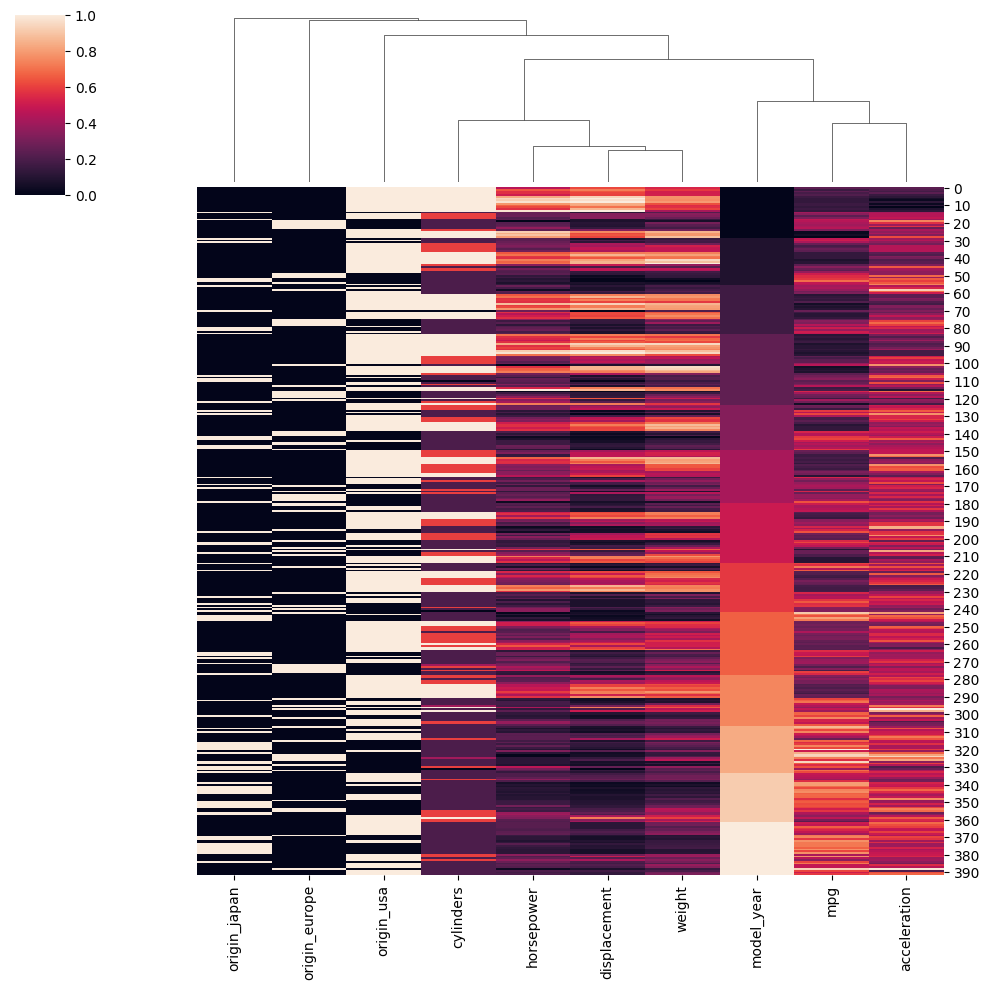

In [18]:
sns.clustermap(scaled_df,row_cluster=False)

Hier valt op dat de dummy variabelen de laatste zijn die samen gegroepeerd worden aangezien zij het verst van elkaar af staan door de 0 en 1 waarden: ze hebben de maximum afstand tov elkaar want als één waarde 1 is, dan moeten de andere nul zijn!Als je dus wil clusteren om te zien welke features aan elkaar gerelateerd zijn, verwijder je best de dummy kolommen. <p>De features waarvan seaborn denkt dat ze het dichtst bij elkaar liggen is displacement (=cilinderinhoud) en weight.</p><p>Daarnaast zijn ook miles per gallon en acceleration aan elkaar gekoppeld, weliswaar iets minder.</p><p>Model year is ook gekoppeld aan miles per gallon, wat ook logisch is enz...</p>

In [19]:
# Alternatieve manier:
scaled_df.corr()

,mpg,cylinders,displacement,horsepower,weight,acceleration,model_year,origin_europe,origin_japan,origin_usa
mpg,1.000000,-0.777618,-0.805127,-0.778427,-0.832244,0.423329,0.580541,0.244313,0.451454,-0.565161
cylinders,-0.777618,1.000000,0.950823,0.842983,0.897527,-0.504683,-0.345647,-0.352324,-0.404209,0.610494
displacement,-0.805127,0.950823,1.000000,0.897257,0.932994,-0.543800,-0.369855,-0.371633,-0.440825,0.655936
horsepower,-0.778427,0.842983,0.897257,1.000000,0.864538,-0.689196,-0.416361,-0.284948,-0.321936,0.489625
weight,-0.832244,0.897527,0.932994,0.864538,1.000000,-0.416839,-0.309120,-0.293841,-0.447929,0.600978
acceleration,0.423329,-0.504683,-0.543800,-0.689196,-0.416839,1.000000,0.290316,0.208298,0.115020,-0.258224
model_year,0.580541,-0.345647,-0.369855,-0.416361,-0.309120,0.290316,1.000000,-0.037745,0.199841,-0.136065
origin_europe,0.244313,-0.352324,-0.371633,-0.284948,-0.293841,0.208298,-0.037745,1.000000,-0.230157,-0.591434
origin_japan,0.451454,-0.404209,-0.440825,-0.321936,-0.447929,0.115020,0.199841,-0.230157,1.000000,-0.648583
origin_usa,-0.565161,0.610494,0.655936,0.489625,0.600978,-0.258224,-0.136065,-0.591434,-0.648583,1.000000


<Figure size 1500x800 with 0 Axes>

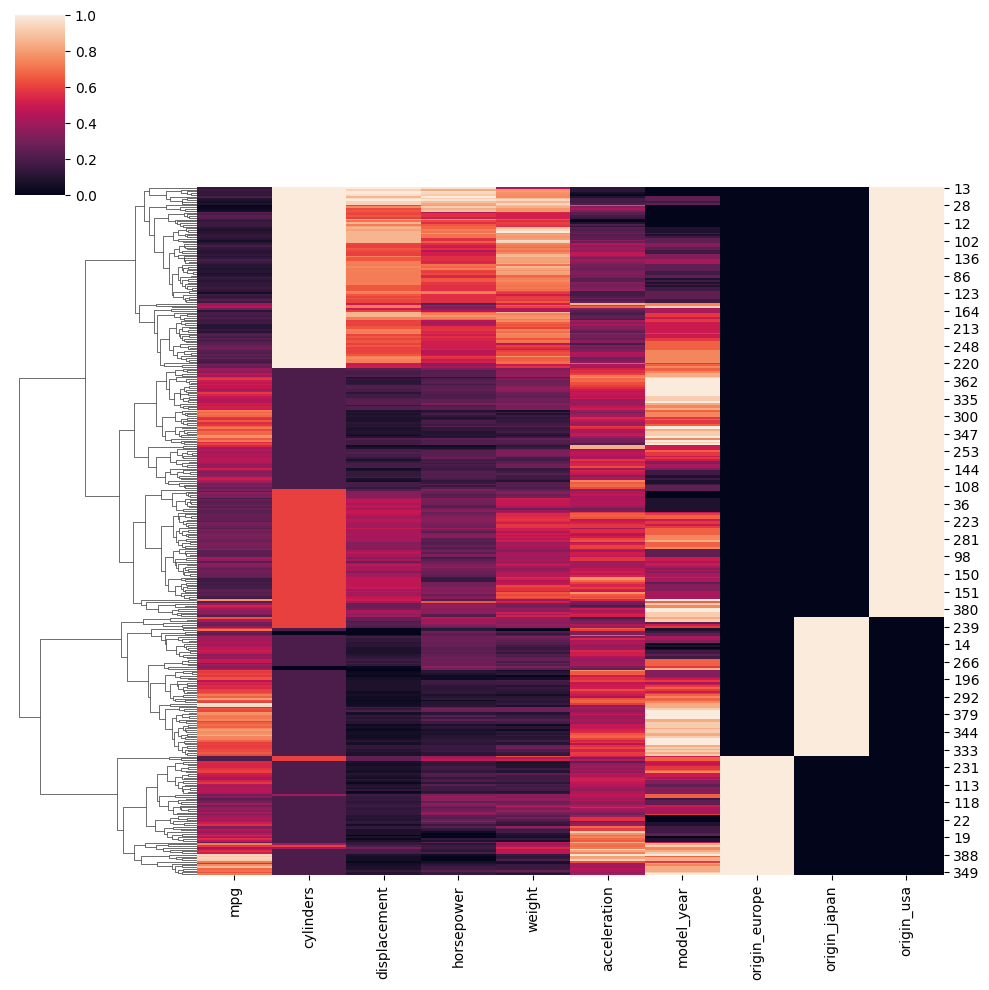

In [23]:
# Dit is eigenlijk niet waar we naar op zoek zijn: we willen rijen clusteren, niet de kolommen!
plt.figure(figsize=(15,8))
sns.clustermap(scaled_df, col_cluster=False)
plt.show()

<p>Nu zien we dat de features opnieuw geordend zijn, en dat data gegroepeerd is op basis van features.  Rechts zien we vb de clustering gebaseerd op origin: de witte zijn de usa wagens, de zwarte de niet-usa wagens...   Vervolgens de Japanse enz...  </p><p>Daarna hebben we cilinders als belangrijkste parameter; hier is het voorkomen van redelijk grote blokken te wijten aan het feit dat het aantal cilinders ook een categorische waarde is; je kan niet 2,1 cilinder hebben...   </p><p>Bij continue features zie je groepen van lichtere kleuren, donkerder kleuren enz... vb bij displacement.  </p><p>Dit is een goede visualisatie, maar zal niet werken voor grote datasets, en de labels kunnen niet worden bekomen met seaborn.

# Hierarchisch Clusteren - deel 2: Scikit-Learn

Deel 1 was visualisatie met seaborn.  Nu zien we chiërarchisch clusteren met seaborn.  We zullen 2 afzonderlijke methodes bekijken: het op voorhand kiezen van het aantal clusters, en daarna het gebruik van het dendrogram en kiezen van een distance treshold om sklearn ons te laten gidsen voor het aantal clusters.

In [24]:
# opgepast: Hiërarchical clustering valt onder AgglomerativeClustering importeren!
from sklearn.cluster import AgglomerativeClustering

In [25]:
# Uit de visualisatie hierboven kunnen we opmaken dat 4 clusters een redelijke keuze is
model = AgglomerativeClustering(n_clusters=4)

In [26]:
# we werken met de scaled data!
cluster_labels = model.fit_predict(scaled_df)

In [27]:
cluster_labels

array([1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 3, 0, 0, 0, 3, 2, 2, 2,
       2, 2, 0, 1, 1, 1, 1, 3, 0, 3, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1,
       0, 0, 0, 0, 0, 2, 2, 2, 3, 3, 2, 0, 3, 0, 2, 0, 0, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 3, 1, 1, 1, 1, 2, 2, 2, 2, 0, 3, 3, 0, 3, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 2, 1, 1, 1, 1, 0, 3, 0, 3,
       3, 0, 0, 2, 1, 1, 2, 2, 2, 2, 1, 2, 3, 1, 0, 0, 0, 3, 0, 3, 0, 0,
       0, 0, 1, 1, 1, 1, 1, 2, 2, 2, 3, 3, 0, 2, 2, 3, 3, 2, 0, 0, 0, 0,
       1, 1, 1, 1, 0, 0, 0, 0, 0, 1, 1, 3, 0, 0, 0, 3, 2, 3, 0, 2, 0, 2,
       2, 2, 2, 3, 2, 2, 0, 0, 2, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 2, 3, 0,
       0, 0, 0, 2, 3, 3, 0, 2, 1, 2, 3, 2, 1, 1, 1, 1, 3, 0, 2, 0, 3, 1,
       1, 1, 1, 0, 0, 0, 0, 1, 1, 1, 1, 2, 0, 3, 0, 0, 0, 3, 2, 3, 2, 3,
       2, 0, 3, 3, 3, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 1,
       0, 3, 3, 0, 3, 0, 0, 3, 2, 2, 2, 2, 2, 3, 0, 0, 0, 0, 0, 1, 1, 1,
       1, 1, 1, 1, 1, 2, 3, 0, 0, 2, 1, 2, 1, 0, 0,

<Axes: xlabel='mpg', ylabel='weight'>

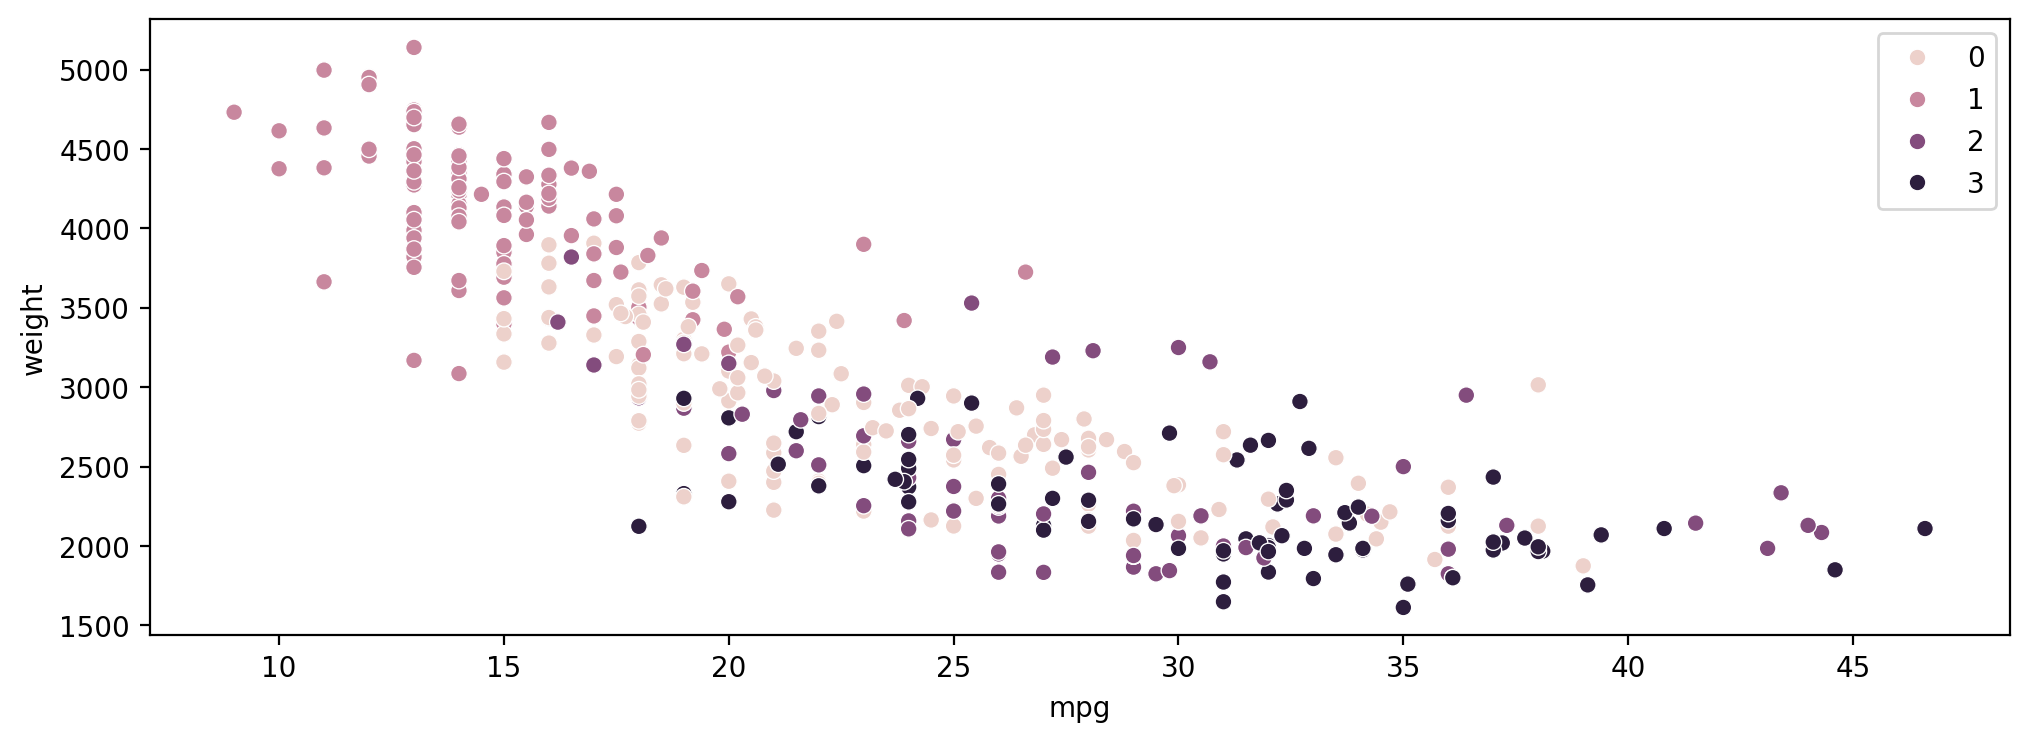

In [28]:
# visualisatie tov een feature (je kan zelf de feature kiezen)
plt.figure(figsize=(12,4),dpi=200)
sns.scatterplot(data=df,x='mpg',y='weight',hue=cluster_labels)

Interpretatie van de resultaten van clustering is steeds moeilijk, want er is geen correct antwoord.  We kunnen enkel beoordelen wat het algoritme in het algemeen doet.  In dit geval lijkt het erop dat er een onderscheid is tussen enerzijds de zware wagens die vele verbruiken, en anderzijds de lichtere wagens die efficiënter zijn.  Je zou hetzelfde kunnen doen voor mpg vs horsepower:

<Axes: xlabel='mpg', ylabel='horsepower'>

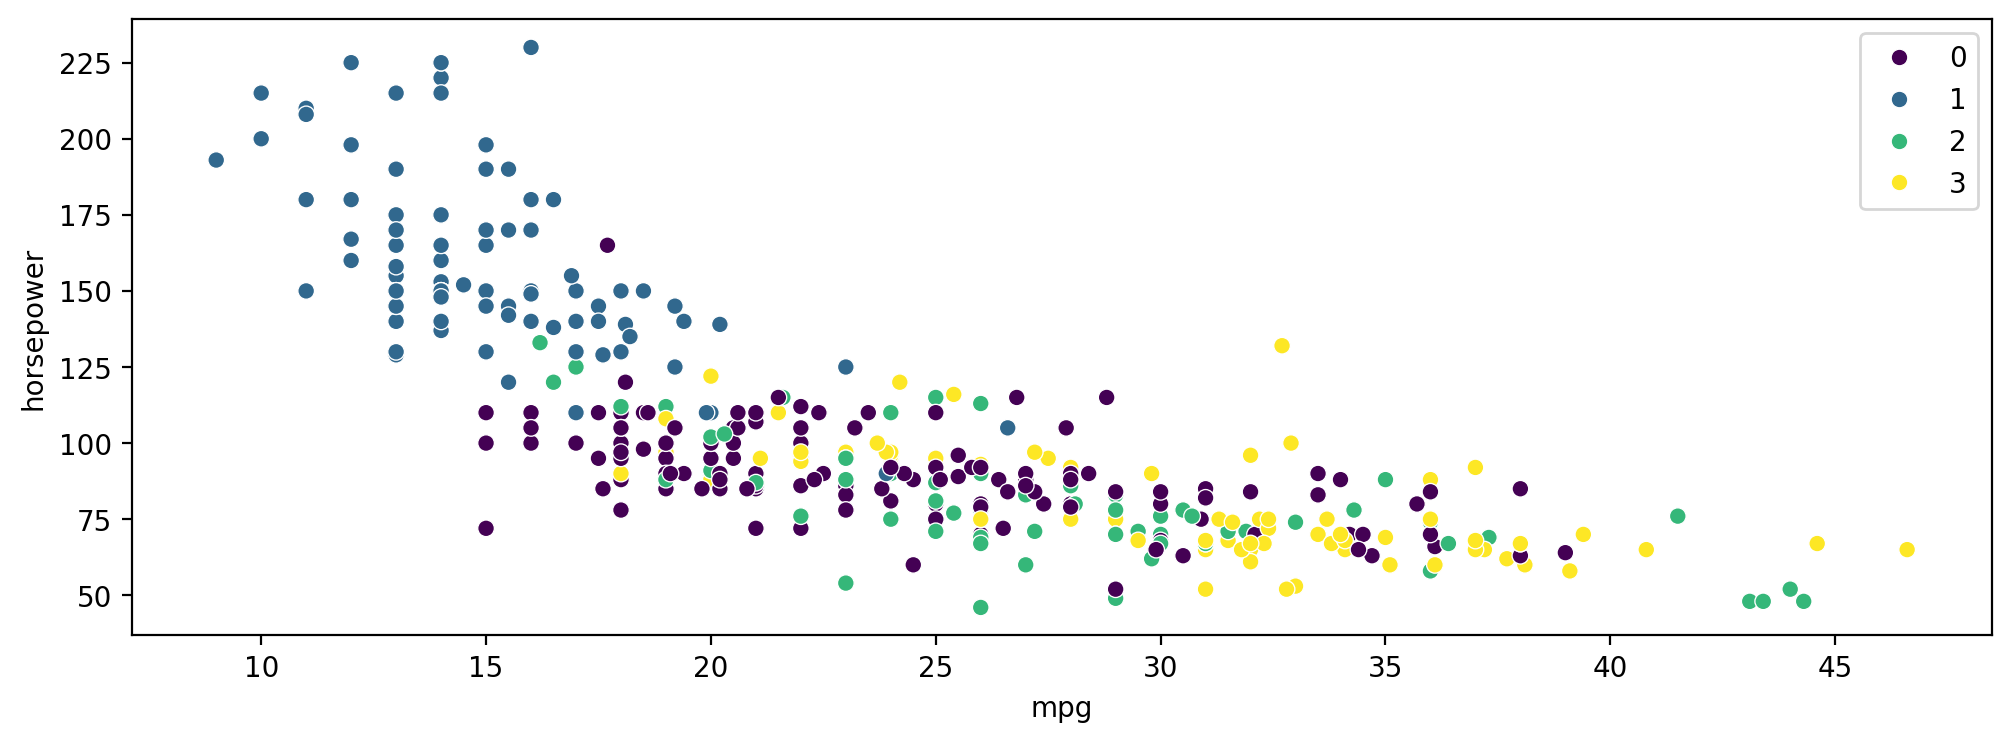

In [29]:
# visualisatie tov een feature (je kan zelf de feature kiezen)
plt.figure(figsize=(12,4),dpi=200)
sns.scatterplot(data=df,x='mpg',y='horsepower',hue=cluster_labels, palette='viridis')

Je kan uiteraard ook het aantal clusters wijzigen!

## Het aantal clusters ontdekken met Dendrogrammen

De online documentatie:
https://docs.scipy.org/doc/scipy/reference/generated/scipy.cluster.hierarchy.dendrogram.html

#### We gaan uit van elk punt wat start als zijn eigen cluster

We hebben bij AgglomerativeClustering een affinity parameter.  Dit is de afstandsmaat die gebruikt moet worden om de koppeling (linkage) te berekenen tussen een punt en een cluster.  Het is aan te raden om de default euclidische afstand te gebruiken, omdat dit helpt bij de interpretatie later wanneer we ook de min max scaler gebruiken.  Bij 1 feature is de afstand maximaal 1, bij meerdere features is de afstand maximaal de vierkantswortel van het aantal features.

Zie documentatie scikit learn voor AgglomerativeClustering: indien we een distance_treshold willen gebruiken, moet n_clusters op None!  De distance_treshold is is de linkage distance treshold waarboven clusters **niet** zullen worden samengevoegd.  We kiezen nu als waarde voor  distance_treshold 0.  Dit betekent dat als clusters een linkage distance van meer dan nul hebben, ze niet worden samengevoegd.  Wat is het verwachte resultaat? Niks zal worden samengevoegd!  Dit komt overeen met Kmeans clustering met K = n.

In [33]:
model = AgglomerativeClustering(n_clusters=None,distance_threshold=0)

In [34]:
cluster_labels = model.fit_predict(scaled_df)

In [35]:
cluster_labels

array([247, 252, 360, 302, 326, 381, 384, 338, 300, 279, 217, 311, 377,
       281, 232, 334, 272, 375, 354, 333, 317, 345, 329, 289, 305, 383,
       290, 205, 355, 269, 202, 144, 245, 297, 386, 358, 199, 337, 330,
       339, 293, 352, 283, 196, 253, 168, 378, 331, 201, 268, 256, 361,
       250, 197, 246, 371, 324, 230, 203, 261, 380, 376, 308, 389, 332,
       306, 236, 391, 350, 274, 288, 313, 231, 298, 100, 295, 210, 248,
       187, 390, 373, 266, 307, 379, 212, 357, 191, 314, 208, 249, 343,
       294, 374, 322, 323, 362, 188, 296, 369, 286, 251, 229, 244, 285,
       349, 365, 259, 213, 276, 215, 222, 204, 359, 287, 166, 387, 291,
       220, 216, 260, 129, 367, 340, 346, 301, 342, 228, 388, 370, 218,
       255, 327, 347, 278, 271, 258, 282, 318, 273, 123, 172, 382, 363,
       356, 195, 280, 239, 364, 267, 351, 186, 257, 277, 299, 127, 366,
       234, 385, 192, 372, 292, 233, 270, 263, 133, 165, 161, 198,  97,
       315, 134, 207, 147, 175, 262, 348,  98, 214,  48, 353, 17

In [36]:
len(cluster_labels)

392

Elke wagen heeft zijn eigen cluster! Deze waarden zijn de cluster ids, niet de ids van de rijen!

In [37]:
# dit kunnen we ook visualiseren met scipy
# dit is de visualisatie functie voor het dendrogram die dit automatisch visualiseert op basis van een linkage matrix
from scipy.cluster.hierarchy import dendrogram

from scipy.cluster import hierarchy   # deze module bevat functies voor hiërarchisch clusteren.
# je zou ook volgende kunnen importeren:
# from scipy.cluster.hierarchy import linkage

### Linkage Matrix

De linkage matrix bevat informatie over hoe clusters worden gecombineerd in elke stap van de hiërarchische clustering.

hierarchy staat hier voor de module die wordt gebruikt om een linkage matrix te genereren uit de fusie-informatie die gegenereerd wordt door een hiërarchisch clusteringproces - dus niet voor het clusteringproces zelf.

model.children_: dit attribuut van een hiërarchisch clustermodel bevat een array waarin elke rij een samenvoeging tussen twee clusters voorstelt. De rijen zijn gesorteerd op de volgorde waarin deze samenvoegingen plaatsvonden, de eerste rij is dus de eerste fusie die plaatsvond, en de laatste rij is de laatste fusie. Elke rij bevat de indices van de twee clusters die in die stap zijn samengevoegd.

linkage_matrix = hierarchy.linkage(model.children_) gebruikt de fusie-informatie uit model.children_ om een linkage matrix te creëren. Deze matrix wordt dan gebruikt voor (onder andere) het plotten van een dendrogram.

In [38]:
linkage_matrix = hierarchy.linkage(model.children_)

In [39]:
linkage_matrix

array([[ 67.        , 161.        ,   1.41421356,   2.        ],
       [ 10.        ,  45.        ,   1.41421356,   2.        ],
       [ 47.        ,  99.        ,   1.41421356,   2.        ],
       ...,
       [340.        , 777.        ,  56.40035461, 389.        ],
       [332.        , 778.        ,  58.69412236, 390.        ],
       [349.        , 779.        ,  75.32595834, 391.        ]])

**Elke rij in een linkage matrix vertegenwoordigt een fusie tussen twee clusters en bestaat uit vier elementen:**

**Index van de eerste cluster:** Dit is de index van de eerste cluster (of datapunt) die wordt samengevoegd. In deze context zijn indices 67 en 10 voorbeelden van de eerste cluster in de eerste twee fusies.

**Index van de tweede cluster:** Dit is de index van de tweede cluster (of datapunt) die wordt samengevoegd. In deze context zijn 161 en 45 de indices van de tweede cluster in de eerste twee fusies.

**Afstand of dissimilariteit tussen de clusters:** Dit getal geeft de afstand of dissimilariteit tussen de twee clusters die worden gecombineerd aan. Het vertelt hoe "ver" of "verschillend" de clusters van elkaar zijn op het moment dat ze worden samengevoegd. Bijvoorbeeld, 1.41421356 is de afstand tussen de clusters in de eerste drie vermelde fusies.

**Aantal oorspronkelijke items in de nieuwe cluster:** Na de fusie vormen de twee clusters samen een nieuwe cluster. Dit getal geeft aan hoeveel of datapunten zich nu in deze nieuwe cluster bevinden. Dit getal is 2 voor de eerste drie fusies, wat betekent dat elk van die fusies twee oorspronkelijke items samenbracht.

De volgorde van de fusies is van boven naar beneden, waarbij elke stap in het proces een cluster creëert die steeds groter wordt tot uiteindelijk alle datapunten zijn samengevoegd in één enkele cluster. De laatste fusies, zoals die met de afstanden 56.40035461, 58.69412236, en 75.32595834, zijn de stappen die plaatsvonden aan het einde van het proces, waarbij de grootste clusters werden gecombineerd.

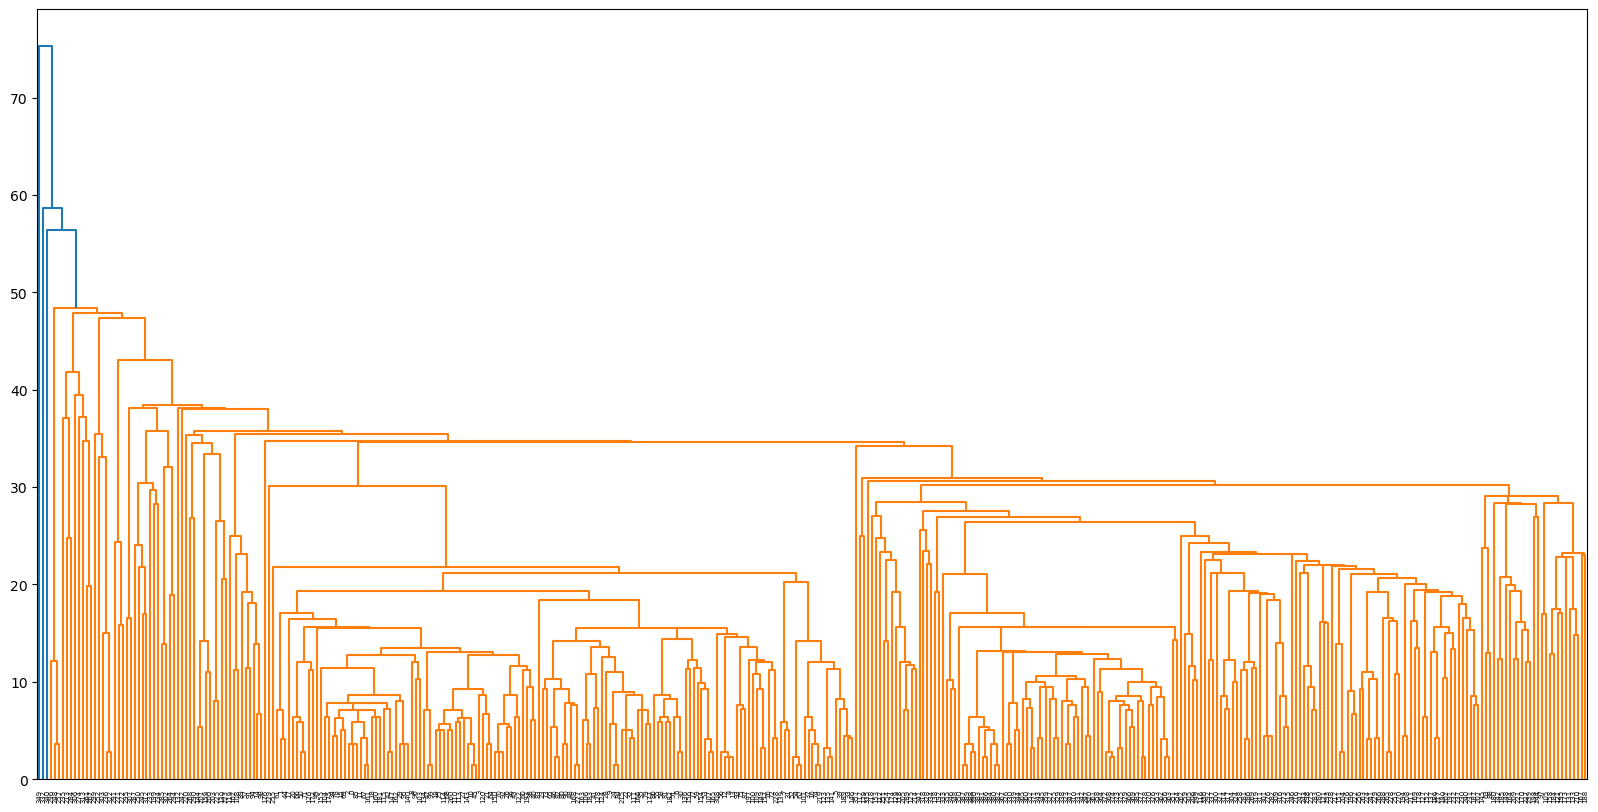

In [40]:
# de linkage matrix bevat alle informatie die nodig is om het dendrogram te plotten.
plt.figure(figsize=(20,10))
# Opgepast! Deze plot kan lang duren...
dn = hierarchy.dendrogram(linkage_matrix)

Elk van de punten onderaan komt overeen mer 1 wagen in de dataset! Onderaan zijn er zeer veel koppelingen telkens tussen 2 wagens.  Dit is wat de linkage matrix start.  Zie hierboven: je zou in dit dendrogram de wagens 67 en 161 moeten terugvinden met een verbinding ertussen.  De hoogte van deze verbinding is 1.414

Volledig bovenaan het dendrogram zie je de laatste samenvoeging: deze voegt 349 en 779 (dit is een grote cluster) samen, en de hoogte is 75.33.  Er zitten 391 punten onder, wat overeenkomt met n-1 fusies. Na de laatste fusie zitten alle punten in 1 cluster.

### Beperken van het dendrogram (truncation methods)

Je kan nu dit dendrogram "afsnijden" op een bepaalde manier: 
<p>lastp geeft het aantal splitsingen weer.  Onderaan wordt vaak naar clustersnummers verwezen die je niet kan interpreteren!  Dit kan wel handig zijn om het aantal gewenste clusters te bepalen.  Zo kan je dan terug naar boven en ipv met distance treshold opnieuw met n_clusters werken.</p> 
<p>level: dit is een andere truncation methode die het aantal levels bepaalt die worden weergegeven.  Elke "T-connectie" is een dergelijk level.</p>

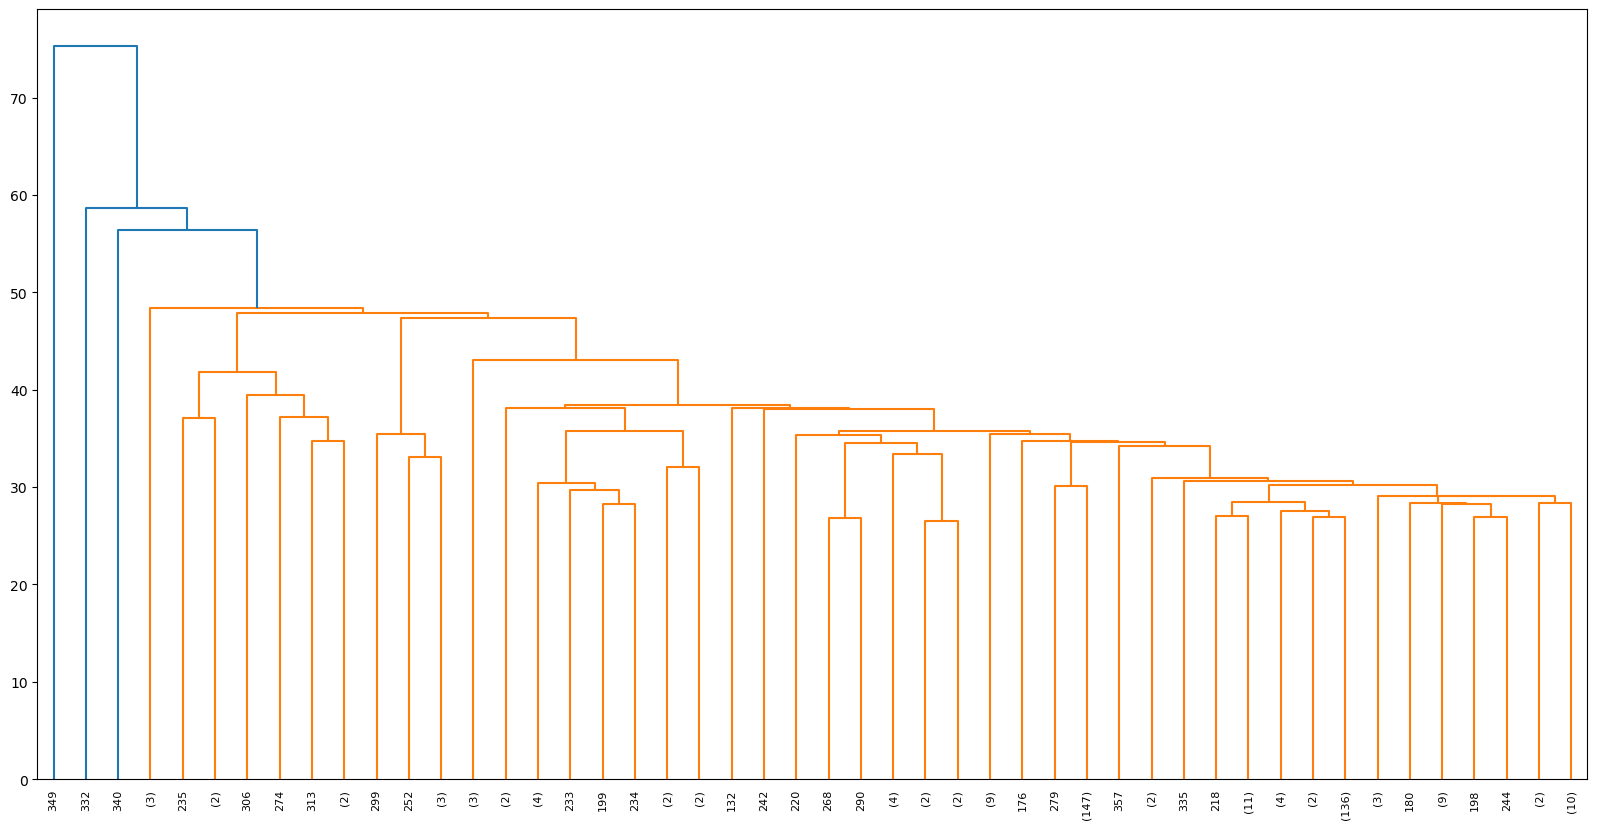

In [41]:
plt.figure(figsize=(20,10))
dn = hierarchy.dendrogram(linkage_matrix,truncate_mode='lastp',p=48)

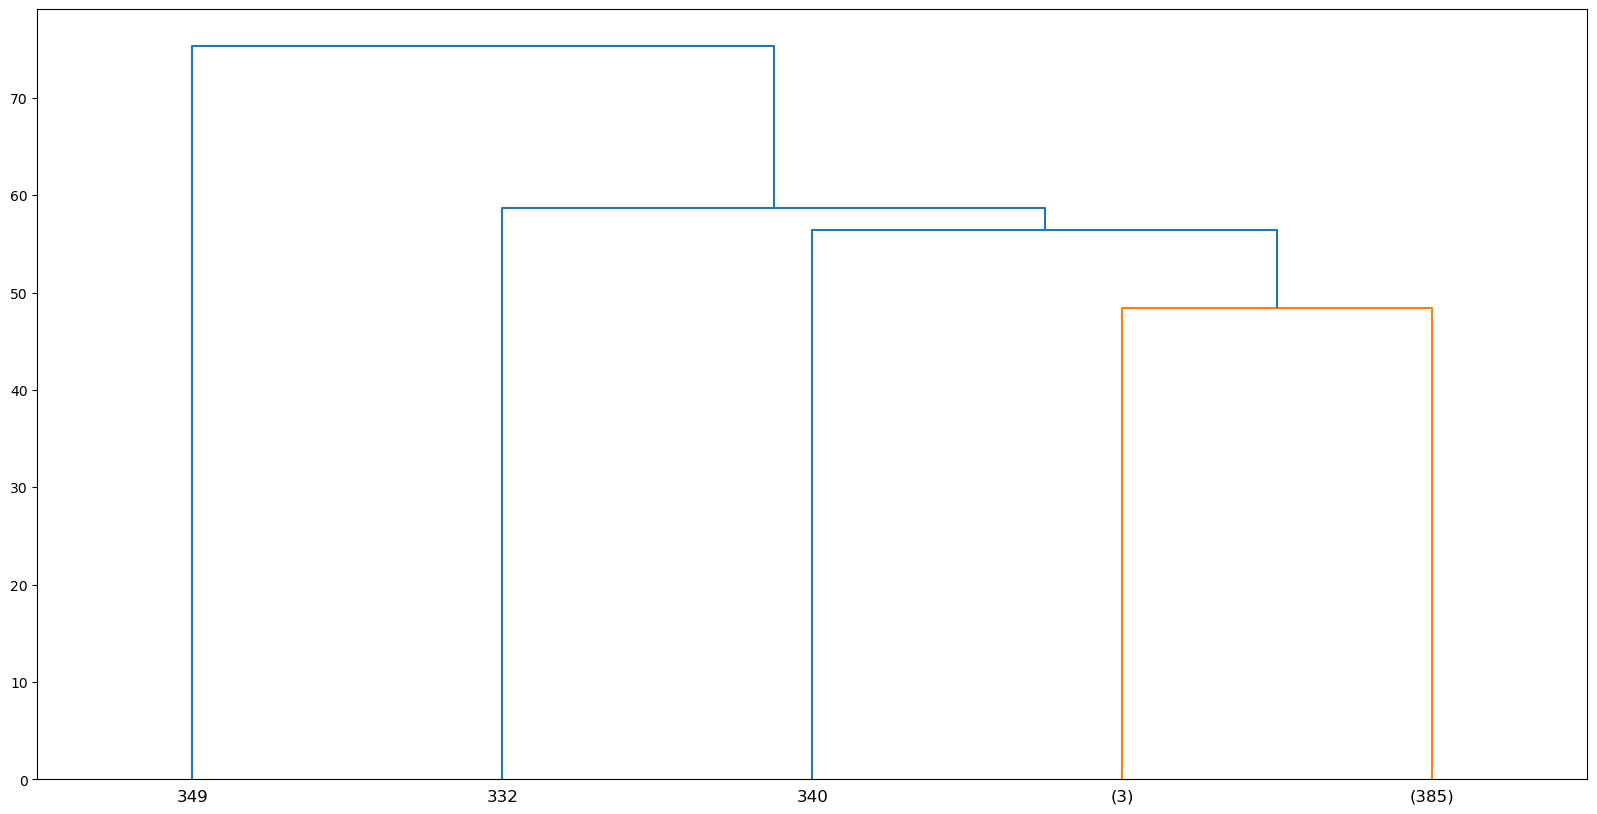

In [42]:
plt.figure(figsize=(20,10))
dn = hierarchy.dendrogram(linkage_matrix,truncate_mode='level',p=3)

## Het aantal clusters ontdekken met een tresholdwaarde voor afstand

Zie eerder: wat is de maximum mogelijke afstand tussen 2 punten?
-> Euclidische afstand: https://en.wikipedia.org/wiki/Euclidean_distance

In [43]:
np.sqrt(len(scaled_df.columns)) 
# 10 features dus wortel(10) is de theoretisch maximale afstand tussen 2 punten in onze min max geschaalde feature ruimte.

3.1622776601683795

**Is dit een realistische waarde?**

In [44]:
scaled_df.describe()

,mpg,cylinders,displacement,horsepower,weight,acceleration,model_year,origin_europe,origin_japan,origin_usa
count,392.000000,392.000000,392.000000,392.000000,392.000000,392.000000,392.000000,392.000000,392.000000,392.000000
mean,0.384200,0.494388,0.326646,0.317768,0.386897,0.448888,0.498299,0.173469,0.201531,0.625000
std,0.207580,0.341157,0.270398,0.209191,0.240829,0.164218,0.306978,0.379136,0.401656,0.484742
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.212766,0.200000,0.095607,0.157609,0.173589,0.343750,0.250000,0.000000,0.000000,0.000000
50%,0.365691,0.200000,0.214470,0.258152,0.337539,0.446429,0.500000,0.000000,0.000000,1.000000
75%,0.531915,1.000000,0.536822,0.434783,0.567550,0.537202,0.750000,0.000000,0.000000,1.000000
max,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


**Hieronder zoeken we de id's van de minst en meest efficiënte wagens.  Deze zijn hogerop in de scatterplot ook te zien: helemaal links en helemaal rechts!**

In [45]:
# id van de wagen met de maximale waarde voor mpg
scaled_df['mpg'].idxmax()  

320

In [46]:
# id van de wagen met de minimale waarde voor mpg
scaled_df['mpg'].idxmin()  

28

In [47]:
# berekenen van de echte grootste afstand tussen de 2 "uiterste" wagens
# https://stackoverflow.com/questions/1401712/how-can-the-euclidean-distance-be-calculated-with-numpy
a = scaled_df.iloc[320]
b = scaled_df.iloc[28]
dist = np.linalg.norm(a-b)

In [48]:
# dit is de grootste afstand tussen 2 wagens in onze dataset!
# dit is de afstand tussen 2 punten, niet tussen 2 clusters!
# de afstanden tussen clusters werden ook weergegeven
dist

2.3852929970374714

**De afstanden tussen de clusters zijn veel groter dan de maximum afstand tussen 2 punten van de dataset.  Hoe is dit mogelijk?**

De afstand tussen de clusters wordt default bepaald door Ward's methode.  

model = AgglomerativeClustering(n_clusters=None,distance_threshold=2)

default: linkage='ward'.  Deze methode meet de afstand tussen clusters als een toename van de totale variantie binnen de clusters, en dus kan de 'afstand' aanzienlijk toenemen als grotere clusters worden gecombineerd (75 voor de laatste merge in de linkage matrix).  

**Hoe bepaal je nu een gepaste waarde voor de distance_treshold?**
Inspectie van de Dendrogram: Een visuele inspectie van de dendrogram kan helpen bij het identificeren van een geschikte drempel. Zoek naar een groot verschil (een "sprong") in de afstand tussen opeenvolgende fusies. Dit kan duiden op een natuurlijke clustering structuur.

Elbow Method: Net als bij de K-means clustering, kan de elbow method ook worden gebruikt bij hiërarchische clustering. Plot de afstanden (of toename van de totale som van kwadraten) bij elke fusie en zoek naar een punt waar de toename van afstand plotseling afneemt (de "elleboog"). Dit kan een goede afstandsdrempel zijn.

Domeinkennis en Context: Gebruik specifieke kennis van het domein of de context om te bepalen wat een zinvolle afstandsdrempel is. Bijvoorbeeld, als clusters bepaalde fysieke groepen of categorieën moeten vertegenwoordigen, kan domeinkennis helpen om een drempelwaarde te bepalen.

Validatie tegen externe criteria: Als je externe criteria of labels hebt, kun je de clusteringresultaten valideren door te kijken hoe goed de gevormde clusters overeenkomen met deze externe benchmarks.

Trial en error: Experimenteer met verschillende drempelwaarden en evalueer de resultaten. Je zou kunnen beginnen met een drempel die een hoger aantal clusters oplevert dan verwacht en deze geleidelijk verhogen totdat de resultaten logisch lijken.

Bij het gebruik van Ward's methode is het cruciaal om rekening te houden met de neiging van de methode om clusters van ongeveer gelijke grootte te vormen. Dit kan betekenen dat een drempel die werkt voor datasets met natuurlijk gelijke clusterformaten niet even goed werkt voor datasets waarin enkele grote of enkele kleine clusters aanwezig zijn.

In [49]:
distances = linkage_matrix[:, 2]

### Elbow Method

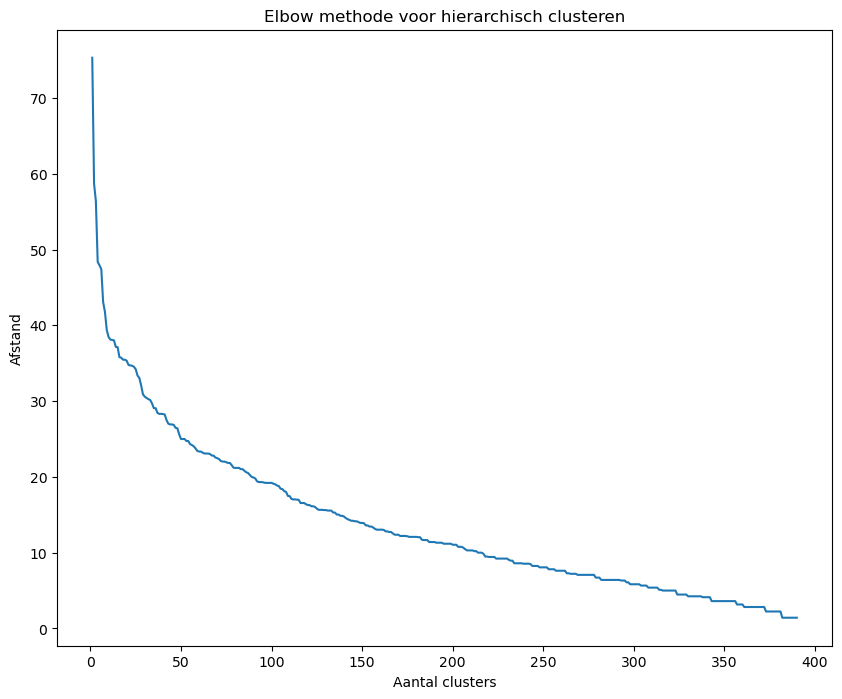

In [50]:
# Plot de afstanden
plt.figure(figsize=(10, 8))
plt.plot(range(1, len(distances)+1), distances[::-1])
plt.title('Elbow methode voor hierarchisch clusteren')
plt.xlabel('Aantal clusters')
plt.ylabel('Afstand')
plt.show()

### Maken van een Model gebaseerd op Distance Threshold

* distance_threshold
    * De linkage afstand treshold boven dewelke clusters niet meer worden samengevoegd.  

In [51]:
model = AgglomerativeClustering(n_clusters=None,distance_threshold=2)

In [52]:
cluster_labels = model.fit_predict(scaled_data)

In [53]:
cluster_labels

array([ 3,  3,  3,  3,  3,  3,  3,  3,  3,  3,  3,  3,  3,  3,  1,  4,  4,
        4,  1,  0,  0,  0,  0,  0,  4,  3,  3,  3,  3,  1,  7,  1,  4,  4,
        4,  4,  4,  3,  3,  3,  3,  3,  3,  3,  4,  7,  4,  4,  7,  0,  0,
        0,  1,  1,  0,  7,  1,  7,  0,  7,  7,  3,  3,  3,  3,  3,  3,  3,
        3,  3,  1,  3,  3,  3,  3,  0,  0,  0,  0,  7,  1,  1,  7,  1,  3,
        3,  3,  3,  3,  3,  3,  3,  3,  3,  3,  3,  4,  4,  4,  4,  4,  0,
        3,  3,  3,  3,  4,  1,  7,  1,  1,  7,  4,  0,  3,  3,  0,  0,  0,
        0,  3,  0, 10,  3,  4,  4,  4,  1,  7,  1,  7,  4,  4,  4,  3,  3,
        3,  3,  3,  0,  0,  0,  1,  1,  7,  0,  0,  1,  1,  0,  4,  4,  4,
        4,  5,  3,  3,  3,  4,  4,  4,  4,  4,  5,  5,  1,  7,  4,  7,  1,
        0,  1,  4,  0,  4,  0,  0,  0,  0,  1,  0,  0,  7,  7,  0,  5,  5,
        5,  5,  4,  4,  4,  4,  7,  7,  0,  1,  9,  4,  9,  4,  0,  1,  1,
        7,  0,  5,  8, 10,  0,  5,  5,  5,  5,  1,  2,  8,  7,  1,  5,  5,
        5,  5,  9,  9,  9

In [54]:
np.unique(cluster_labels)

array([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10], dtype=int64)

11 clusters werden gemaakt!